# Exploratory Data Analysis (EDA): Google Trends, HCUP, & U.S. Census Bureau, & NEW temporal & spatial variables
**Author:** J. Casey Brookshier  
**Date:** August 12, 2026

## Objective

Prepare and explore a state-year Engineered dataset (with new predictors) to evaluate whether suicide- and crisis-related Google Trends search activity is associated with future state-level inpatient psychiatric admissions.


## Workflow

**Summarize → Visualize → Assess Relationships → Identify Preprocessing Needs**


In [2]:
import os

print(os.getcwd())
print(os.path.exists(
    "/Users/caseybrookshier/Desktop/Data Science job attainment planning/DS Portfolio github friendly/Team-Rho-Capstone-Project.cb/data/processed"
))

/Users/caseybrookshier
True


EDA REPORT — ENGINEERED STATE-YEAR DATASET v2
Shape: (452, 14)
Observations: 452
States: 46
Years: 2014 - 2023
Google Trends predictors: 8
Engineered predictors: 2
Total predictors: 10
Duplicate rows: 0

Missing values:


state_population                 0
admission_rate_per_100k          0
suicidal thoughts_lag1           2
suicide hotline_lag1             2
self harm_lag1                   2
mental health crisis_lag1        2
suicide prevention_lag1          2
crisis hotline_lag1              2
psychiatric hospital_lag1        2
depression help_lag1             2
admission_rate_lag2             92
neighbor_admission_rate_lag1    44
dtype: int64


TABLE 1 — DESCRIPTIVE STATISTICS


,Variable,Count,Mean,Median,Std Dev,Minimum,Q1,Q3,Maximum,Skew,Kurtosis
0,state_population,452.00,"6,856,513.13","4,995,066.50","7,384,389.65","579,054.00","1,957,910.75","8,565,122.25","39,437,610.00",2.44,6.86
1,admission_rate_per_100k,452.00,401.80,395.85,148.15,110.11,285.13,497.96,826.91,0.55,-0.05
2,suicidal thoughts_lag1,450.00,38.57,44.17,24.53,0.00,15.52,56.56,88.42,-0.32,-1.08
3,suicide hotline_lag1,450.00,36.55,39.42,19.31,0.00,24.08,52.37,71.00,-0.37,-0.92
4,self harm_lag1,450.00,43.82,45.54,21.53,0.00,32.42,57.60,90.75,-0.30,-0.51
5,mental health crisis_lag1,450.00,16.69,7.54,20.78,0.00,0.00,29.10,87.33,1.18,0.46
6,suicide prevention_lag1,450.00,25.07,27.33,10.30,0.00,18.65,32.92,50.67,-0.56,-0.37
7,crisis hotline_lag1,450.00,24.04,14.08,24.54,0.00,0.00,47.56,82.17,0.54,-1.21
8,psychiatric hospital_lag1,450.00,44.76,55.21,28.62,0.00,14.08,69.73,89.50,-0.40,-1.38
9,depression help_lag1,450.00,51.06,58.21,22.21,0.00,41.50,67.65,81.83,-1.00,-0.16


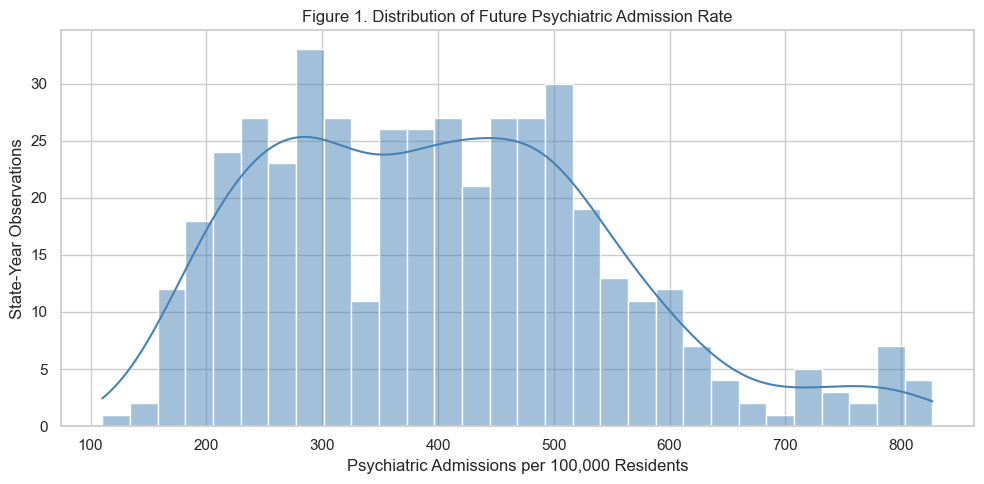

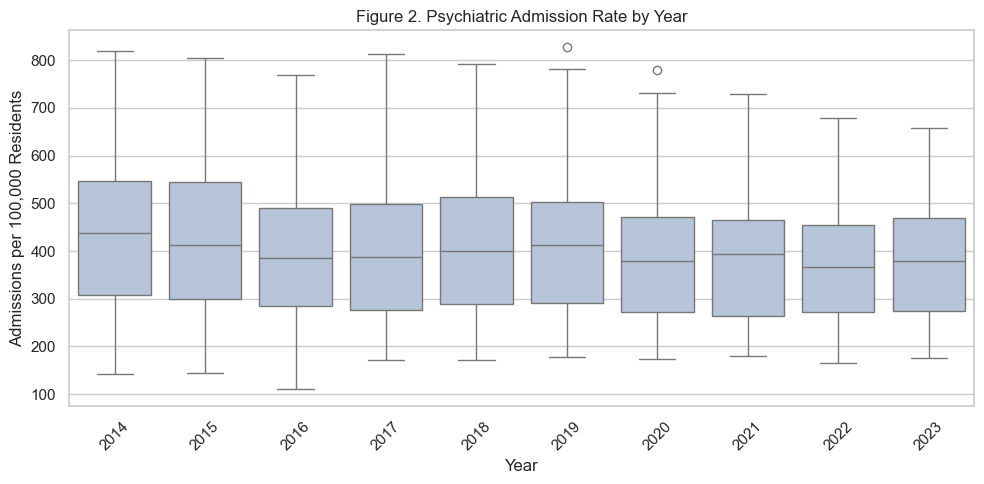

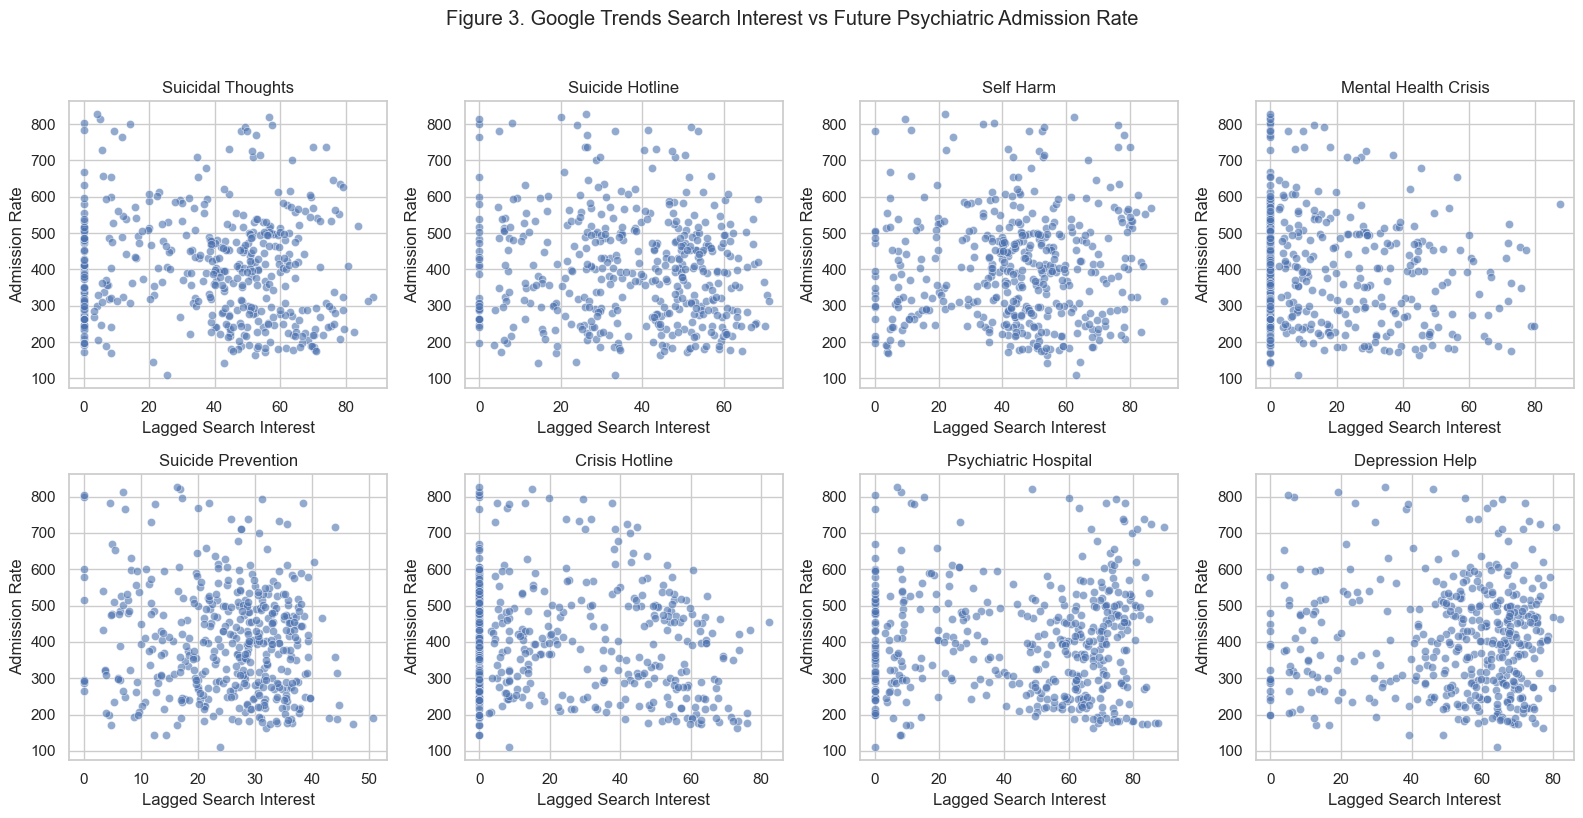

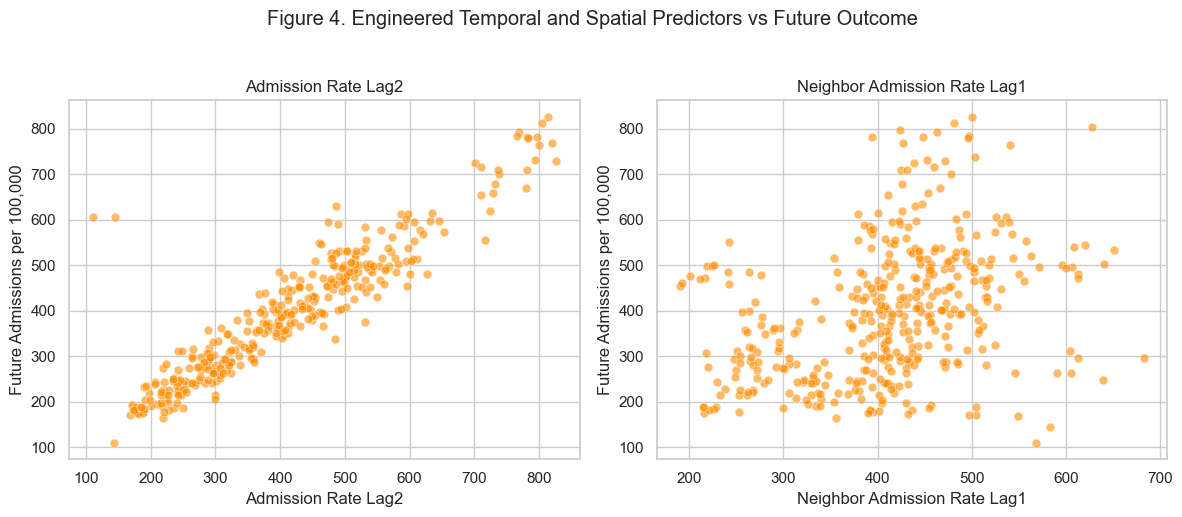

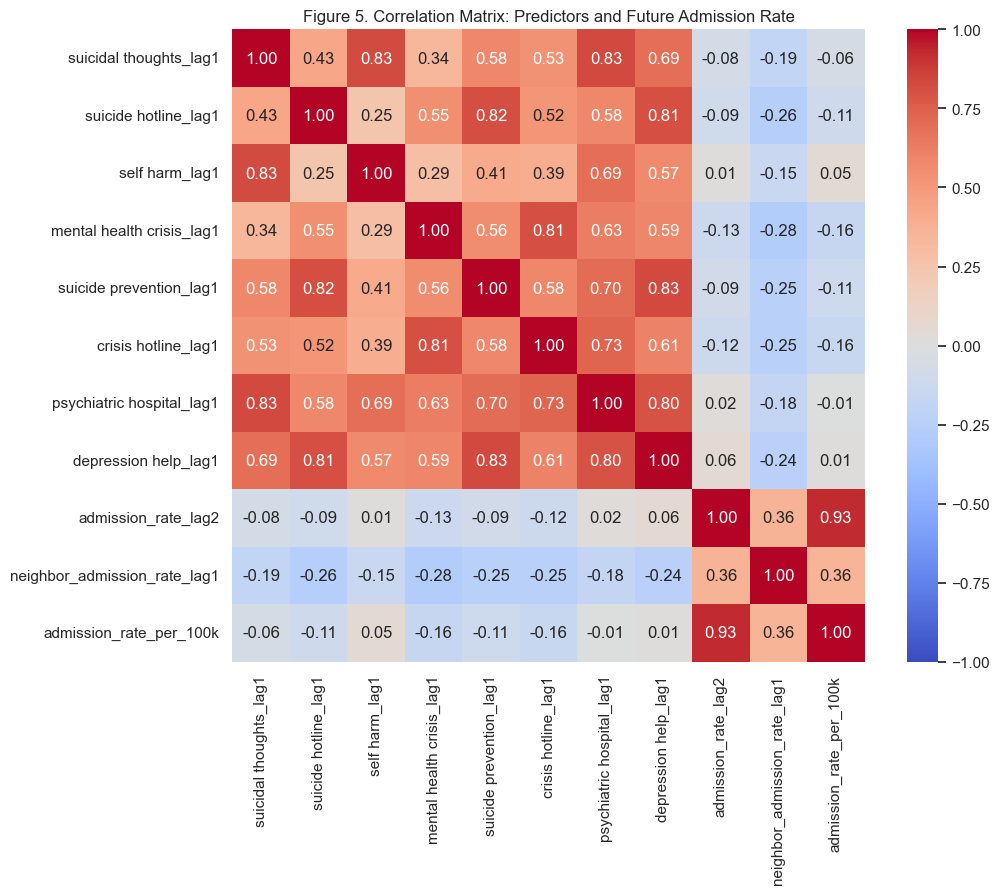


TABLE 2 — PREDICTOR CORRELATIONS WITH FUTURE ADMISSION RATE


,Predictor,Correlation
9,admission_rate_lag2,0.93
8,neighbor_admission_rate_lag1,0.35
0,mental health crisis_lag1,-0.16
1,crisis hotline_lag1,-0.16
2,suicide prevention_lag1,-0.12
3,suicide hotline_lag1,-0.11
4,suicidal thoughts_lag1,-0.06
7,self harm_lag1,0.05
6,depression help_lag1,0.01
5,psychiatric hospital_lag1,-0.01



EDA SUMMARY
The engineered dataset contains 452 state-year observations across 46 states from 2014 through 2023.
The outcome has a mean of 401.80 and a standard deviation of 148.15 admissions per 100,000 residents.
The dataset contains 8 lagged Google Trends predictors and 2 engineered temporal/spatial predictors.
There are 0 duplicate rows.

Missing predictor values:


suicidal thoughts_lag1           2
suicide hotline_lag1             2
self harm_lag1                   2
mental health crisis_lag1        2
suicide prevention_lag1          2
crisis hotline_lag1              2
psychiatric hospital_lag1        2
depression help_lag1             2
admission_rate_lag2             92
neighbor_admission_rate_lag1    44
dtype: int64


Outcome correlations:


,Predictor,Correlation
9,admission_rate_lag2,0.93
8,neighbor_admission_rate_lag1,0.35
0,mental health crisis_lag1,-0.16
1,crisis hotline_lag1,-0.16
2,suicide prevention_lag1,-0.12
3,suicide hotline_lag1,-0.11
4,suicidal thoughts_lag1,-0.06
7,self harm_lag1,0.05
6,depression help_lag1,0.01
5,psychiatric hospital_lag1,-0.01



EDA outputs saved to:
/Users/caseybrookshier/Desktop/Data Science job attainment planning/DS Portfolio github friendly/Team-Rho-Capstone-Project.cb/figures/EDA.eng

EDA COMPLETE


In [17]:

# EDA REPORT — ENGINEERED STATE-YEAR DATASET 



import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# data paths

DATA = Path(
    "/Users/caseybrookshier/Desktop/Data Science job attainment planning/"
    "DS Portfolio github friendly/"
    "Team-Rho-Capstone-Project.cb/data/processed/Engineered_Data_v2/"
    "team_rho_state_year_prediction_dataset_ENGINEERED_v2.csv"
)

OUT = Path(
    "/Users/caseybrookshier/Desktop/Data Science job attainment planning/"
    "DS Portfolio github friendly/"
    "Team-Rho-Capstone-Project.cb/figures/EDA.eng"
)

OUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA)

TARGET = "admission_rate_per_100k"
GROUP = "State"
TIME = "Year"

# variable definitions

TREND_COLS = [
    c for c in [
        "suicidal thoughts_lag1",
        "suicide hotline_lag1",
        "self harm_lag1",
        "mental health crisis_lag1",
        "suicide prevention_lag1",
        "crisis hotline_lag1",
        "psychiatric hospital_lag1",
        "depression help_lag1"
    ]
    if c in df.columns
]

ENGINEERED_COLS = [
    c for c in [
        "admission_rate_lag2",
        "neighbor_admission_rate_lag1"
    ]
    if c in df.columns
]

PREDICTOR_COLS = list(
    dict.fromkeys(TREND_COLS + ENGINEERED_COLS)
)

EDA_NUMERIC = list(
    dict.fromkeys(
        c for c in (
            ["state_population", TARGET] + PREDICTOR_COLS
        )
        if c in df.columns
    )
)

# data quality check

print("EDA REPORT — ENGINEERED STATE-YEAR DATASET v2")
print("=" * 60)

print("Shape:", df.shape)
print("Observations:", len(df))
print("States:", df[GROUP].nunique())
print("Years:", df[TIME].min(), "-", df[TIME].max())
print("Google Trends predictors:", len(TREND_COLS))
print("Engineered predictors:", len(ENGINEERED_COLS))
print("Total predictors:", len(PREDICTOR_COLS))
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
display(df[EDA_NUMERIC].isna().sum())

# table 1 descriptive statistics

numeric = df[EDA_NUMERIC].copy()

desc = numeric.describe().T

# construct the table so column names are stable.
table1 = pd.DataFrame({
    "Variable": desc.index,
    "Count": desc["count"].values,
    "Mean": numeric.mean().values,
    "Median": numeric.median().values,
    "Std Dev": numeric.std().values,
    "Minimum": numeric.min().values,
    "Q1": numeric.quantile(0.25).values,
    "Q3": numeric.quantile(0.75).values,
    "Maximum": numeric.max().values,
    "Skew": numeric.skew().values,
    "Kurtosis": numeric.kurtosis().values
})

table1 = table1.round(2)

print("\nTABLE 1 — DESCRIPTIVE STATISTICS")
display(table1)

table1.to_csv(
    OUT / "Table_1_Descriptive_Statistics.csv",
    index=False
)

# target distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x=TARGET,
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title(
    "Figure 1. Distribution of Future Psychiatric Admission Rate"
)
plt.xlabel("Psychiatric Admissions per 100,000 Residents")
plt.ylabel("State-Year Observations")

plt.tight_layout()

plt.savefig(
    OUT / "Figure_1_Target_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# outcome by year

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x=TIME,
    y=TARGET,
    color="lightsteelblue"
)

plt.title(
    "Figure 2. Psychiatric Admission Rate by Year"
)
plt.xlabel("Year")
plt.ylabel("Admissions per 100,000 Residents")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    OUT / "Figure_2_Outcome_by_Year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# google trends vs. future outcome

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

axes = np.asarray(axes).flatten()

for ax, col in zip(axes, TREND_COLS):

    sns.scatterplot(
        data=df,
        x=col,
        y=TARGET,
        ax=ax,
        alpha=0.60,
        s=35
    )

    ax.set_title(
        col.replace("_lag1", "").title()
    )
    ax.set_xlabel("Lagged Search Interest")
    ax.set_ylabel("Admission Rate")

# remove unused axes if fewer than eight trend variables exist.
for ax in axes[len(TREND_COLS):]:
    ax.remove()

fig.suptitle(
    "Figure 3. Google Trends Search Interest vs Future Psychiatric Admission Rate",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    OUT / "Figure_3_Google_Trends_vs_Outcome.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# temporal/spatial engineered predictors

if ENGINEERED_COLS:

    fig, axes = plt.subplots(
        1,
        len(ENGINEERED_COLS),
        figsize=(12, 5)
    )

    if len(ENGINEERED_COLS) == 1:
        axes = [axes]

    for ax, col in zip(axes, ENGINEERED_COLS):

        sns.scatterplot(
            data=df,
            x=col,
            y=TARGET,
            ax=ax,
            alpha=0.60,
            s=40,
            color="darkorange"
        )

        ax.set_title(
            col.replace("_", " ").title()
        )
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel(
            "Future Admissions per 100,000"
        )

    fig.suptitle(
        "Figure 4. Engineered Temporal and Spatial Predictors vs Future Outcome",
        y=1.03
    )

    plt.tight_layout()

    plt.savefig(
        OUT / "Figure_4_Engineered_Predictors.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

# correlation/collinearity

CORR_COLS = list(
    dict.fromkeys(
        PREDICTOR_COLS + [TARGET]
    )
)

corr = df[CORR_COLS].corr()

plt.figure(figsize=(11, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "Figure 5. Correlation Matrix: Predictors and Future Admission Rate"
)

plt.tight_layout()

plt.savefig(
    OUT / "Figure_5_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# correlations w/ outcome

outcome_correlations = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values()
    .rename("Correlation")
    .reset_index()
    .rename(columns={"index": "Predictor"})
)

outcome_correlations["Absolute_Correlation"] = (
    outcome_correlations["Correlation"].abs()
)

table2 = (
    outcome_correlations
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .drop(columns="Absolute_Correlation")
    .round(3)
)

print("\nTABLE 2 — PREDICTOR CORRELATIONS WITH FUTURE ADMISSION RATE")
display(table2)

table2.to_csv(
    OUT / "Table_2_Outcome_Correlations.csv",
    index=False
)

# EDA summary

print("\nEDA SUMMARY")
print("=" * 60)

print(
    f"The engineered dataset contains {len(df)} state-year observations "
    f"across {df[GROUP].nunique()} states from {df[TIME].min()} "
    f"through {df[TIME].max()}."
)

print(
    f"The outcome has a mean of {df[TARGET].mean():.2f} and "
    f"a standard deviation of {df[TARGET].std():.2f} admissions "
    f"per 100,000 residents."
)

print(
    f"The dataset contains {len(TREND_COLS)} lagged Google Trends "
    f"predictors and {len(ENGINEERED_COLS)} engineered temporal/spatial predictors."
)

print(
    f"There are {df.duplicated().sum()} duplicate rows."
)

print("\nMissing predictor values:")
display(df[PREDICTOR_COLS].isna().sum())

print("\nOutcome correlations:")
display(table2)

print("\nEDA outputs saved to:")
print(OUT)

print("\nEDA COMPLETE")